# Phase 2: EDA — 탐색적 데이터 분석
**과제**: 기상 및 발전 데이터를 활용한 대기오염물질 배출 최적화 모델 개발 (한국남동발전 삼천포)

## 분석 목표
1. 데이터 품질 확인 (결측치, 이상치)
2. 계절/월별 배출 패턴 파악
3. 기상 변수 × 배출량 상관관계
4. 연료 믹스 × 배출량 관계
5. **대기정체 구간** 식별 (핵심 인사이트)
6. 신재생 발전 비중 증가 → 배출량 변화

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from pathlib import Path

matplotlib.rcParams['font.family'] = 'AppleGothic'
matplotlib.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', 50)

PROCESSED_DIR = Path('../data/processed')
REPORT_DIR = Path('../reports')
REPORT_DIR.mkdir(exist_ok=True)

TARGET_COLS = ['SOx', 'NOx', '먼지']
TARGET_LABELS = {'SOx': 'SOx (kg/일)', 'NOx': 'NOx (kg/일)', '먼지': '먼지 (kg/일)'}

master = pd.read_csv(PROCESSED_DIR / 'master_dataset.csv', parse_dates=['date'])
print(f'마스터 데이터: {master.shape}')
print(f'기간: {master["date"].min().date()} ~ {master["date"].max().date()}')
master.head()

마스터 데이터: (2123, 36)
기간: 2020-07-16 ~ 2026-05-09


,date,SOx,NOx,먼지,SOx_conc,NOx_conc,dust_conc,n_units,temp_mean,humidity_mean,wind_dir,wind_speed_mean,precipitation,wind_sin,wind_cos,stagnation_idx,유연탄,LNG,oil_ton,coal_ratio,lng_ratio,gen_mwh,heat_efficiency,utilization,api_gen_mwh,solar_mwh,wind_mwh,wind_speed_max,pressure_mean,solar_radiation,renewable_mwh,renewable_ratio,month,dayofweek,season,year
0,2020-07-16,498925.845294,1.555739e+06,111556.964180,12.23750,98.13750,39.88125,8,19.58,89.77,68.32,1.35,0.00,0.929262,0.369422,66.496296,13506.806452,0.0,10.451613,1.0,0.0,32330.709677,17.883333,40.093333,NaN,0.0,0.0,13.708391,1003.76570,24.11,0.0,0.0,7,3,summer,2020
1,2020-07-17,553145.514900,1.533093e+06,122518.129245,10.77375,98.28375,38.11125,8,19.55,91.99,57.00,2.05,0.00,0.838671,0.544639,44.873171,13506.806452,0.0,10.451613,1.0,0.0,32330.709677,17.883333,40.093333,NaN,0.0,0.0,10.895577,1005.57690,27.14,0.0,0.0,7,4,summer,2020
2,2020-07-18,526034.253205,1.539783e+06,121284.318937,11.71500,99.62375,30.56125,8,21.63,86.08,117.99,1.96,0.00,0.883030,-0.469317,43.918367,13506.806452,0.0,10.451613,1.0,0.0,32330.709677,17.883333,40.093333,NaN,0.0,0.0,9.021574,1006.29364,13.53,0.0,0.0,7,5,summer,2020
3,2020-07-19,504067.152773,1.541445e+06,123539.761068,10.47000,86.04750,33.05625,8,24.00,99.00,242.87,9.08,7.75,-0.889974,-0.456011,10.903084,13506.806452,0.0,10.451613,1.0,0.0,32330.709677,17.883333,40.093333,NaN,0.0,0.0,21.674870,1004.30230,5.46,0.0,0.0,7,6,summer,2020
4,2020-07-20,559773.602366,1.575632e+06,139324.442524,13.84750,70.91750,34.02875,8,22.61,93.93,110.46,1.11,0.50,0.936916,-0.349553,84.621622,13506.806452,0.0,10.451613,1.0,0.0,32330.709677,17.883333,40.093333,NaN,0.0,0.0,19.652176,1004.22120,8.87,0.0,0.0,7,0,summer,2020


## 1. 데이터 품질 확인

In [2]:
# 결측치 현황
missing = master.isnull().sum()
missing_pct = (missing / len(master) * 100).round(1)
missing_report = pd.DataFrame({'결측수': missing, '결측률(%)': missing_pct})
missing_report = missing_report[missing_report['결측수'] > 0].sort_values('결측률(%)', ascending=False)
print('=== 결측치 현황 ===')
print(missing_report.to_string())

=== 결측치 현황 ===
                 결측수  결측률(%)
wind_sin         570    26.8
wind_cos         570    26.8
wind_dir         570    26.8
api_gen_mwh      543    25.6
solar_radiation   31     1.5
lng_ratio          9     0.4
heat_efficiency    9     0.4
pressure_mean      9     0.4
wind_speed_max     9     0.4
utilization        9     0.4
renewable_ratio    9     0.4
gen_mwh            9     0.4
coal_ratio         9     0.4
oil_ton            9     0.4
LNG                9     0.4
유연탄                9     0.4
temp_mean          2     0.1


In [3]:
# 이상치 탐지 (IQR 방법)
print('=== 이상치 탐지 (IQR 기준) ===')
for col in TARGET_COLS:
    if col not in master.columns:
        continue
    Q1 = master[col].quantile(0.25)
    Q3 = master[col].quantile(0.75)
    IQR = Q3 - Q1
    outlier_mask = (master[col] < Q1 - 1.5*IQR) | (master[col] > Q3 + 1.5*IQR)
    print(f'{col}: 이상치 {outlier_mask.sum()}건 ({outlier_mask.mean()*100:.1f}%), '
          f'범위 [{master[col].min():.1f}, {master[col].max():.1f}]')

# 기초 통계
master[TARGET_COLS].describe().round(1)

=== 이상치 탐지 (IQR 기준) ===
SOx: 이상치 27건 (1.3%), 범위 [42355.1, 1380548.1]
NOx: 이상치 74건 (3.5%), 범위 [3481.9, 2745169.1]
먼지: 이상치 329건 (15.5%), 범위 [5926.6, 27936340.1]


,SOx,NOx,먼지
count,2123.0,2123.0,2123.0
mean,428293.3,710348.6,389195.3
std,204399.9,413083.2,1143847.8
min,42355.1,3481.9,5926.6
25%,285652.1,421285.6,85738.1
50%,401248.0,680330.5,124823.3
75%,556740.8,942929.7,223178.3
max,1380548.1,2745169.1,27936340.1


## 2. 연도별 배출량 추이 (시계열)

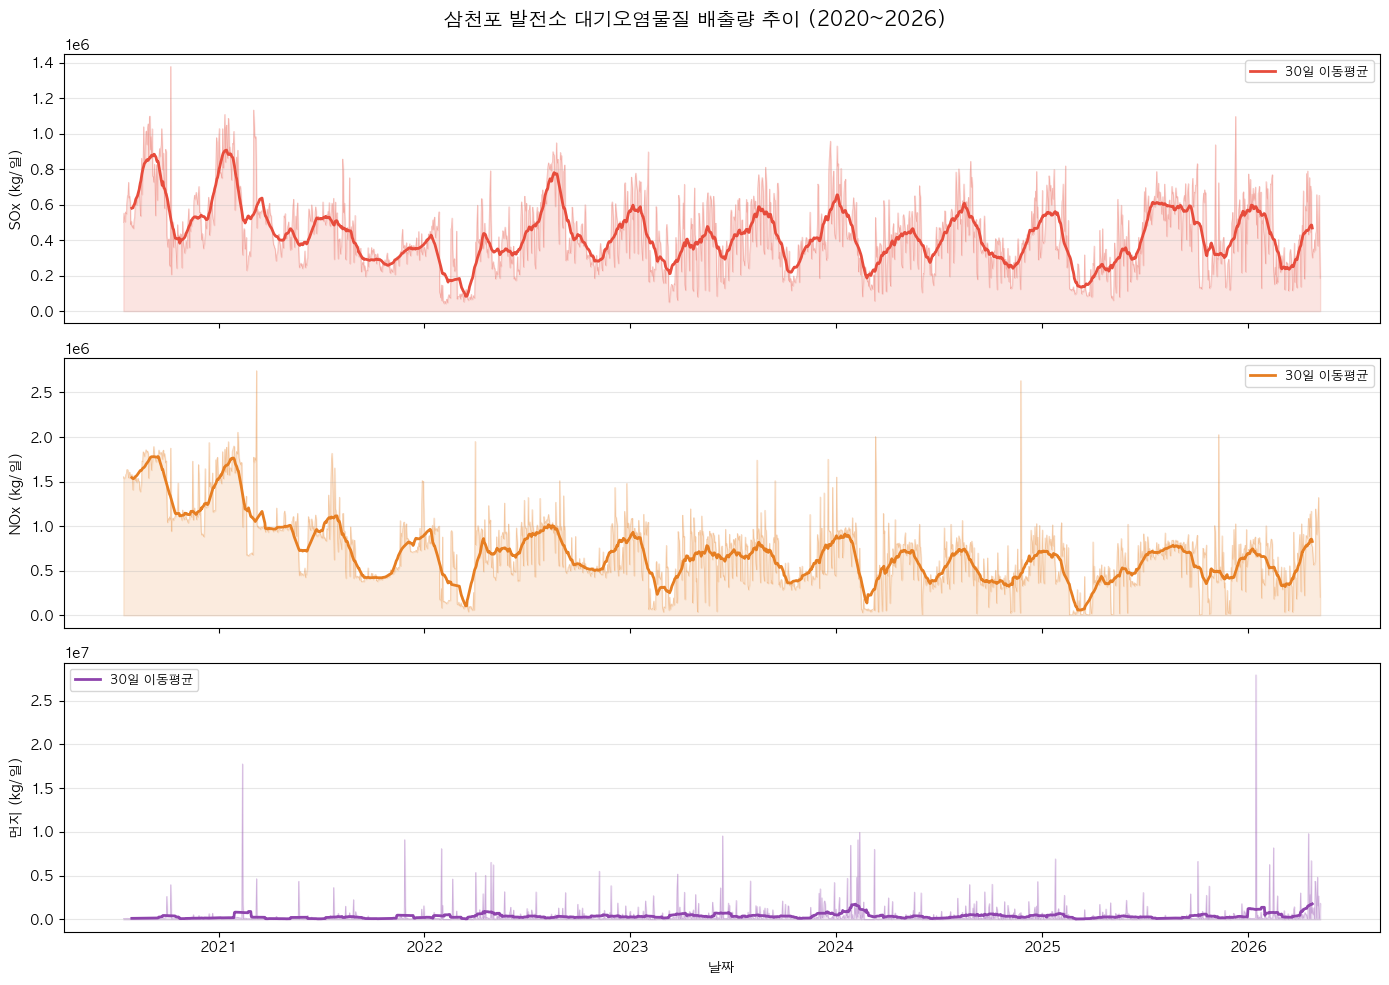

[저장] eda_01_timeseries.png


In [4]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
colors = ['#E74C3C', '#E67E22', '#8E44AD']

for ax, col, color in zip(axes, TARGET_COLS, colors):
    if col not in master.columns:
        continue
    # 30일 이동평균
    roll = master.set_index('date')[col].rolling(30, center=True).mean()
    ax.fill_between(master['date'], master[col], alpha=0.15, color=color)
    ax.plot(master['date'], master[col], alpha=0.3, lw=0.5, color=color)
    ax.plot(roll.index, roll.values, lw=2, color=color, label='30일 이동평균')
    ax.set_ylabel(TARGET_LABELS[col], fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

axes[-1].set_xlabel('날짜')
fig.suptitle('삼천포 발전소 대기오염물질 배출량 추이 (2020~2026)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORT_DIR / 'eda_01_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print('[저장] eda_01_timeseries.png')

## 3. 계절별 / 월별 배출 패턴

/var/folders/nb/1vhq63mx2qqb3nxdjc603zdm0000gn/T/ipykernel_96838/4191748499.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(data_by_season, labels=season_labels, patch_artist=True, notch=False)
/var/folders/nb/1vhq63mx2qqb3nxdjc603zdm0000gn/T/ipykernel_96838/4191748499.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(data_by_season, labels=season_labels, patch_artist=True, notch=False)
/var/folders/nb/1vhq63mx2qqb3nxdjc603zdm0000gn/T/ipykernel_96838/4191748499.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(data_by_season, labels=season_labels, patch_art

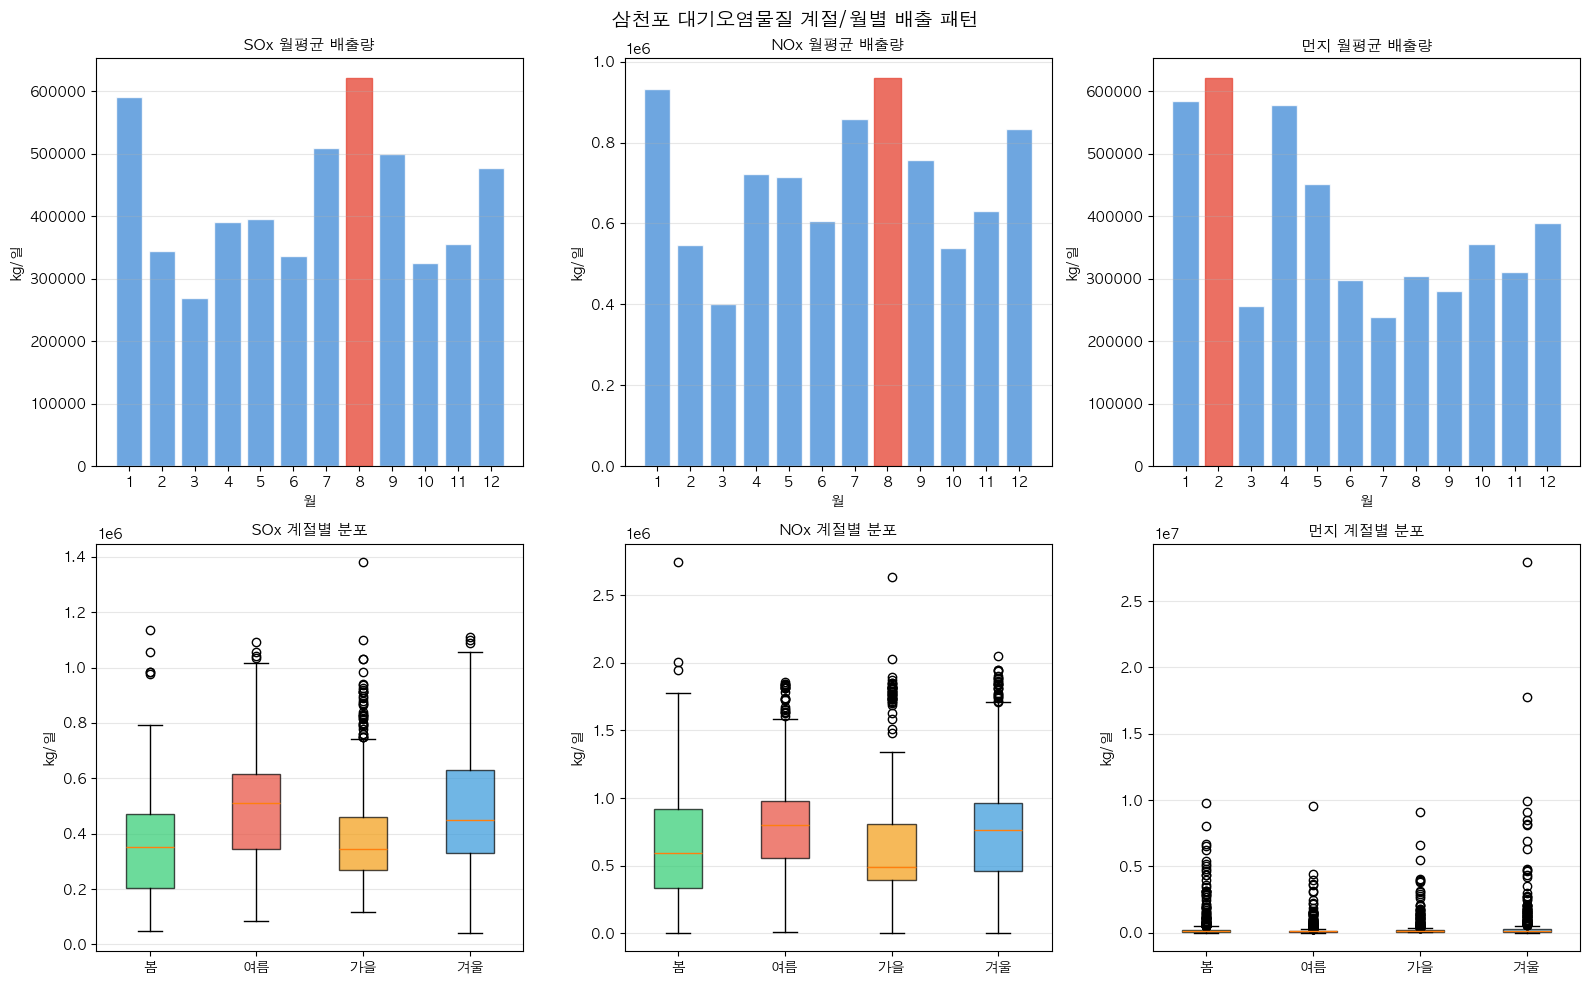

[저장] eda_02_seasonal_pattern.png


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
colors_bar = '#4A90D9'

for i, col in enumerate(TARGET_COLS):
    if col not in master.columns:
        continue

    # 월별 평균 (상단)
    ax = axes[0, i]
    monthly = master.groupby('month')[col].mean()
    bars = ax.bar(monthly.index, monthly.values, color=colors_bar, alpha=0.8, edgecolor='white')
    ax.set_title(f'{col} 월평균 배출량', fontsize=11, fontweight='bold')
    ax.set_xlabel('월')
    ax.set_ylabel('kg/일')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(['1','2','3','4','5','6','7','8','9','10','11','12'])
    # 최대월 표시
    max_month = monthly.idxmax()
    bars[max_month-1].set_color('#E74C3C')
    ax.grid(axis='y', alpha=0.3)

    # 계절별 박스플롯 (하단)
    ax2 = axes[1, i]
    season_order = ['spring', 'summer', 'autumn', 'winter']
    season_labels = ['봄', '여름', '가을', '겨울']
    season_colors = ['#2ECC71', '#E74C3C', '#F39C12', '#3498DB']
    data_by_season = [master[master['season'] == s][col].dropna() for s in season_order]
    bp = ax2.boxplot(data_by_season, labels=season_labels, patch_artist=True, notch=False)
    for patch, color in zip(bp['boxes'], season_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax2.set_title(f'{col} 계절별 분포', fontsize=11, fontweight='bold')
    ax2.set_ylabel('kg/일')
    ax2.grid(axis='y', alpha=0.3)

plt.suptitle('삼천포 대기오염물질 계절/월별 배출 패턴', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORT_DIR / 'eda_02_seasonal_pattern.png', dpi=150, bbox_inches='tight')
plt.show()
print('[저장] eda_02_seasonal_pattern.png')

## 4. 기상 변수 × 배출량 상관관계 히트맵

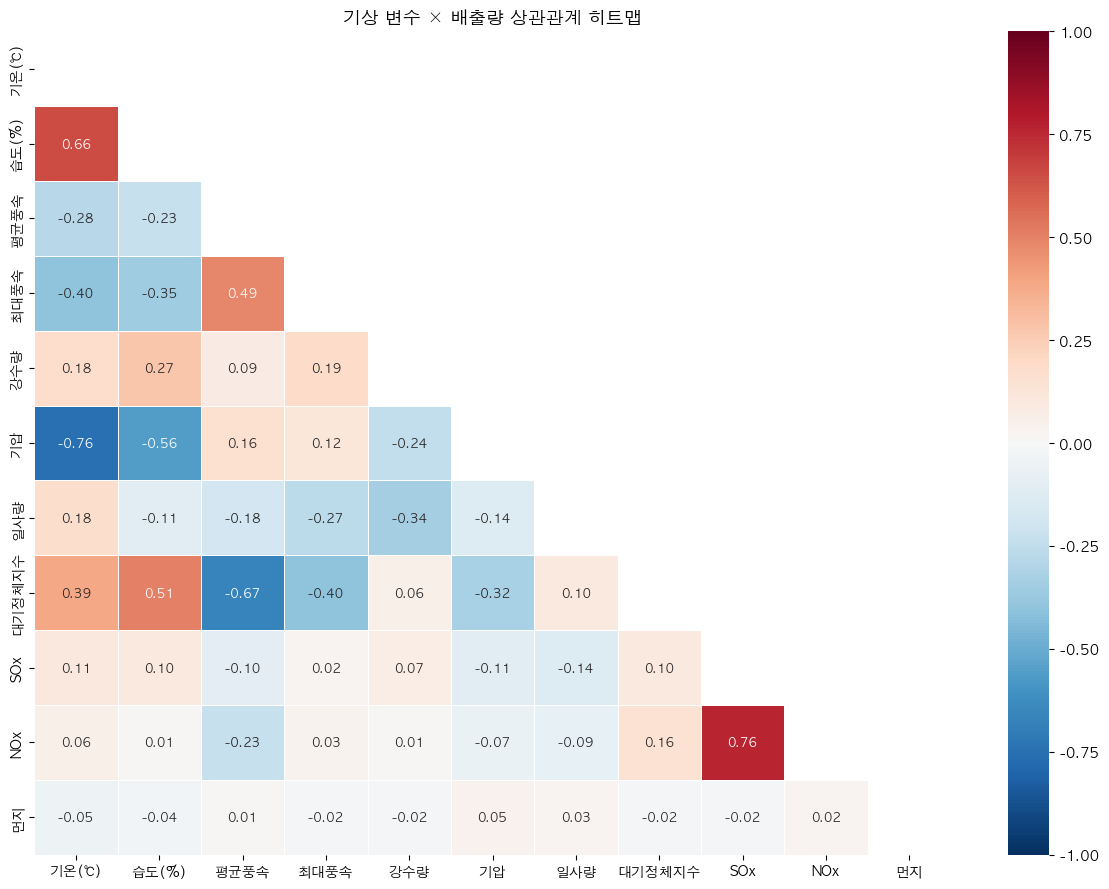

[저장] eda_03_correlation_heatmap.png

배출량과의 주요 상관계수:

  SOx:
일사량       0.140
기압        0.114
기온(℃)     0.109
평균풍속      0.103
대기정체지수    0.099

  NOx:
평균풍속      0.233
대기정체지수    0.155
일사량       0.086
기압        0.065
기온(℃)     0.060

  먼지:
기온(℃)     0.050
기압        0.046
습도(%)     0.036
일사량       0.026
대기정체지수    0.021


In [6]:
weather_cols = ['temp_mean', 'humidity_mean', 'wind_speed_mean', 'wind_speed_max',
                'precipitation', 'pressure_mean', 'solar_radiation', 'stagnation_idx']
weather_labels = {
    'temp_mean': '기온(℃)', 'humidity_mean': '습도(%)', 'wind_speed_mean': '평균풍속',
    'wind_speed_max': '최대풍속', 'precipitation': '강수량', 'pressure_mean': '기압',
    'solar_radiation': '일사량', 'stagnation_idx': '대기정체지수',
    'SOx': 'SOx', 'NOx': 'NOx', '먼지': '먼지'
}

analysis_cols = [c for c in weather_cols + TARGET_COLS if c in master.columns]
corr = master[analysis_cols].corr()
corr_renamed = corr.rename(index=weather_labels, columns=weather_labels)

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr_renamed, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1, ax=ax, mask=mask,
    annot_kws={'size': 9}, linewidths=0.5
)
ax.set_title('기상 변수 × 배출량 상관관계 히트맵', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORT_DIR / 'eda_03_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('[저장] eda_03_correlation_heatmap.png')

print('\n배출량과의 주요 상관계수:')
for t in TARGET_COLS:
    if t in corr.columns:
        top = corr[t].drop(TARGET_COLS, errors='ignore').abs().sort_values(ascending=False).head(5)
        top.index = [weather_labels.get(i, i) for i in top.index]
        print(f'\n  {t}:')
        print(top.round(3).to_string())

## 5. 대기정체 구간 식별 (핵심 인사이트)

=== 대기정체 조건별 배출량 비교 ===
     대기유동 원활 (하위 10%)  대기정체 심각 (상위 10%)  배출량 증가율 (%)
SOx          374003.7          478800.0         28.0
NOx          541262.0          822376.6         51.9
먼지           407897.7          313166.1        -23.2


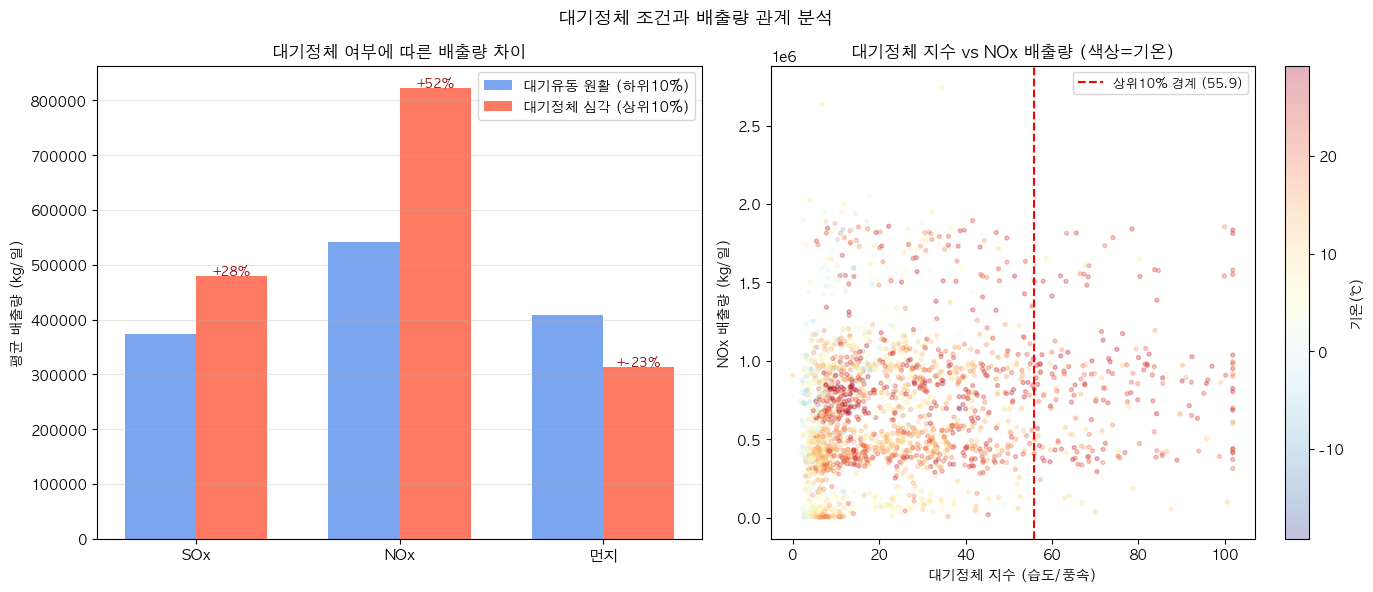

[저장] eda_04_stagnation_analysis.png


In [7]:
if 'stagnation_idx' in master.columns:
    p10 = master['stagnation_idx'].quantile(0.10)
    p90 = master['stagnation_idx'].quantile(0.90)

    low_stag  = master[master['stagnation_idx'] <= p10]
    high_stag = master[master['stagnation_idx'] >= p90]

    compare_df = pd.DataFrame({
        '대기유동 원활 (하위 10%)': low_stag[TARGET_COLS].mean(),
        '대기정체 심각 (상위 10%)': high_stag[TARGET_COLS].mean(),
    })
    compare_df['배출량 증가율 (%)'] = (
        (compare_df['대기정체 심각 (상위 10%)'] - compare_df['대기유동 원활 (하위 10%)'])
        / compare_df['대기유동 원활 (하위 10%)'] * 100
    ).round(1)
    print('=== 대기정체 조건별 배출량 비교 ===')
    print(compare_df.round(1).to_string())

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # 왼쪽: 바 차트
    ax = axes[0]
    x = np.arange(len(TARGET_COLS))
    w = 0.35
    ax.bar(x - w/2, compare_df['대기유동 원활 (하위 10%)'], w,
           label='대기유동 원활 (하위10%)', color='cornflowerblue', alpha=0.85)
    ax.bar(x + w/2, compare_df['대기정체 심각 (상위 10%)'], w,
           label='대기정체 심각 (상위10%)', color='tomato', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(TARGET_COLS, fontsize=11)
    ax.set_ylabel('평균 배출량 (kg/일)')
    ax.set_title('대기정체 여부에 따른 배출량 차이', fontweight='bold')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    for i, (low, high) in enumerate(zip(compare_df['대기유동 원활 (하위 10%)'],
                                         compare_df['대기정체 심각 (상위 10%)'])):
        pct = (high - low) / low * 100
        ax.annotate(f'+{pct:.0f}%', xy=(i + w/2, high), ha='center', va='bottom',
                    fontsize=9, color='darkred', fontweight='bold')

    # 오른쪽: 정체지수 vs NOx 산점도
    ax2 = axes[1]
    sc = ax2.scatter(master['stagnation_idx'].clip(upper=master['stagnation_idx'].quantile(0.99)),
                     master['NOx'], alpha=0.3, s=8, c=master['temp_mean'], cmap='RdYlBu_r')
    plt.colorbar(sc, ax=ax2, label='기온(℃)')
    ax2.axvline(x=p90, color='red', ls='--', lw=1.5, label=f'상위10% 경계 ({p90:.1f})')
    ax2.set_xlabel('대기정체 지수 (습도/풍속)')
    ax2.set_ylabel('NOx 배출량 (kg/일)')
    ax2.set_title('대기정체 지수 vs NOx 배출량 (색상=기온)', fontweight='bold')
    ax2.legend(fontsize=9)

    plt.suptitle('대기정체 조건과 배출량 관계 분석', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(REPORT_DIR / 'eda_04_stagnation_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('[저장] eda_04_stagnation_analysis.png')

## 6. 연료 믹스 × 배출량 관계

/var/folders/nb/1vhq63mx2qqb3nxdjc603zdm0000gn/T/ipykernel_96838/352861710.py:14: RankWarning: Polyfit may be poorly conditioned
  z = np.polyfit(valid['coal_ratio'] * 100, valid[col], 1)
/var/folders/nb/1vhq63mx2qqb3nxdjc603zdm0000gn/T/ipykernel_96838/352861710.py:14: RankWarning: Polyfit may be poorly conditioned
  z = np.polyfit(valid['coal_ratio'] * 100, valid[col], 1)
/var/folders/nb/1vhq63mx2qqb3nxdjc603zdm0000gn/T/ipykernel_96838/352861710.py:14: RankWarning: Polyfit may be poorly conditioned
  z = np.polyfit(valid['coal_ratio'] * 100, valid[col], 1)


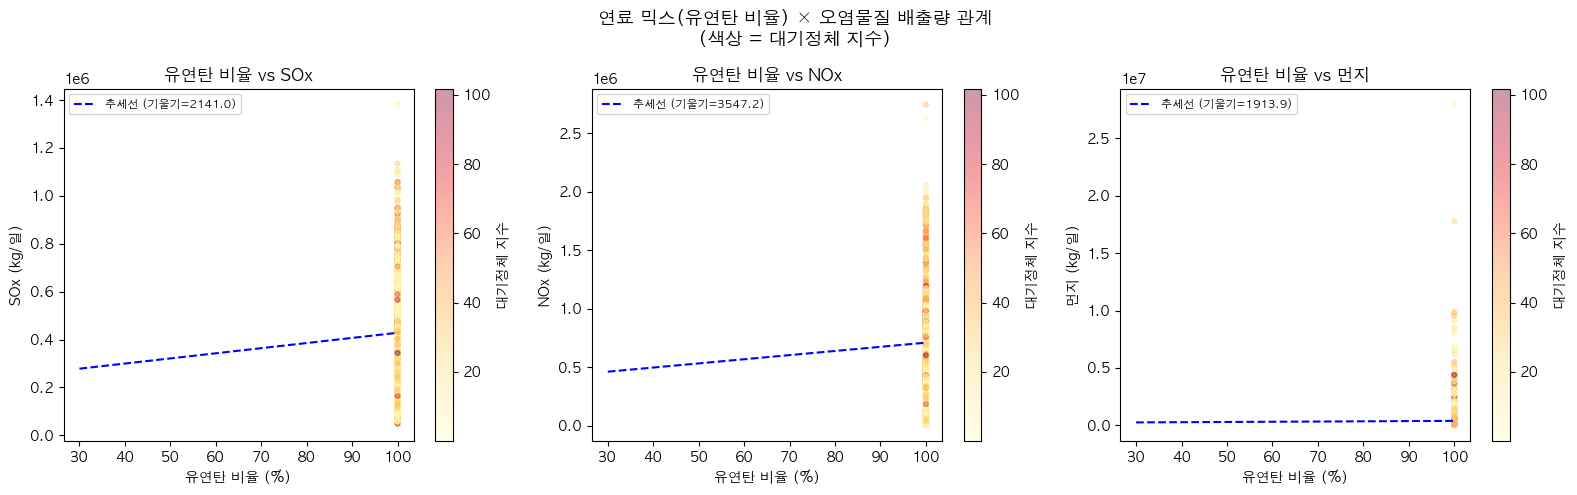

[저장] eda_05_fuel_mix_scatter.png

유연탄 비율 구간별 평균 배출량 (kg/일):
               SOx       NOx        먼지
coal_bin                              
30~40%         NaN       NaN       NaN
40~50%         NaN       NaN       NaN
50~60%         NaN       NaN       NaN
60~70%         NaN       NaN       NaN
70~80%         NaN       NaN       NaN
80~90%         NaN       NaN       NaN
90~100%   428207.1  709436.5  382773.9


/var/folders/nb/1vhq63mx2qqb3nxdjc603zdm0000gn/T/ipykernel_96838/352861710.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(master.groupby('coal_bin')[TARGET_COLS].mean().round(1).to_string())


In [8]:
if 'coal_ratio' in master.columns:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for ax, col in zip(axes, TARGET_COLS):
        if col not in master.columns:
            continue
        sc = ax.scatter(
            master['coal_ratio'] * 100, master[col],
            c=master['stagnation_idx'].clip(upper=master['stagnation_idx'].quantile(0.99)),
            cmap='YlOrRd', alpha=0.4, s=12,
        )
        plt.colorbar(sc, ax=ax, label='대기정체 지수')
        # 추세선
        valid = master[['coal_ratio', col]].dropna()
        z = np.polyfit(valid['coal_ratio'] * 100, valid[col], 1)
        p = np.poly1d(z)
        x_line = np.linspace(30, 100, 100)
        ax.plot(x_line, p(x_line), 'b--', lw=1.5, label=f'추세선 (기울기={z[0]:.1f})')
        ax.set_xlabel('유연탄 비율 (%)')
        ax.set_ylabel(f'{col} (kg/일)')
        ax.set_title(f'유연탄 비율 vs {col}', fontweight='bold')
        ax.legend(fontsize=8)

    plt.suptitle('연료 믹스(유연탄 비율) × 오염물질 배출량 관계\n(색상 = 대기정체 지수)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(REPORT_DIR / 'eda_05_fuel_mix_scatter.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('[저장] eda_05_fuel_mix_scatter.png')

    # 유연탄 비율 구간별 평균 배출량
    master['coal_bin'] = pd.cut(master['coal_ratio'], bins=np.arange(0.3, 1.05, 0.1),
                                 labels=[f'{int(i*100)}~{int((i+0.1)*100)}%' for i in np.arange(0.3, 1.0, 0.1)])
    print('\n유연탄 비율 구간별 평균 배출량 (kg/일):')
    print(master.groupby('coal_bin')[TARGET_COLS].mean().round(1).to_string())

## 7. 신재생 발전 비중 증가 → 배출량 변화

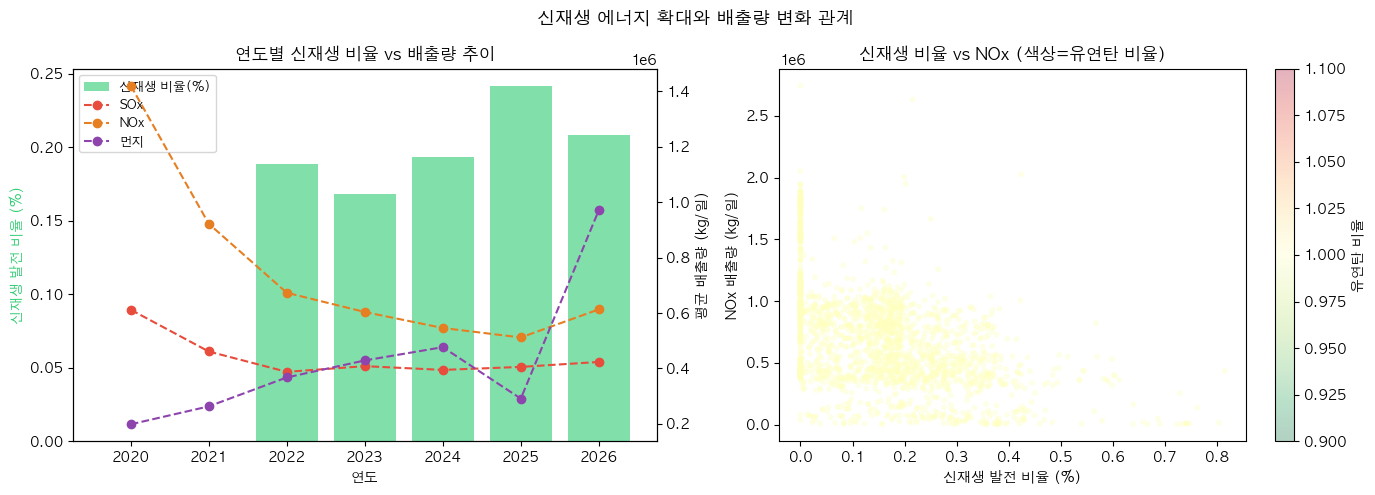

[저장] eda_06_renewable_emission.png

연도별 신재생 발전 비율 및 평균 배출량:
      renewable_ratio         SOx          NOx          먼지
year                                                      
2020            0.000  611960.889  1420713.143  198606.764
2021            0.000  461316.489   922244.390  263284.387
2022            0.002  387807.800   673253.983  367721.796
2023            0.002  408413.142   603860.974  429002.171
2024            0.002  394848.855   546157.180  476910.284
2025            0.002  405679.896   511966.265  291275.078
2026            0.002  423597.062   613297.581  971295.855


In [9]:
if 'renewable_ratio' in master.columns and 'year' in master.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 연도별 신재생 비율 추이
    ax = axes[0]
    yearly = master.groupby('year').agg(
        renewable_ratio=('renewable_ratio', 'mean'),
        **{t: (t, 'mean') for t in TARGET_COLS if t in master.columns}
    ).dropna(how='all')

    ax2_twin = ax.twinx()
    ax.bar(yearly.index, yearly['renewable_ratio'] * 100, color='#2ECC71', alpha=0.6, label='신재생 비율(%)')
    colors_line = ['#E74C3C', '#E67E22', '#8E44AD']
    for col, color in zip(TARGET_COLS, colors_line):
        if col in yearly.columns:
            ax2_twin.plot(yearly.index, yearly[col], 'o--', color=color, lw=1.5, ms=6, label=col)
    ax.set_xlabel('연도')
    ax.set_ylabel('신재생 발전 비율 (%)', color='#2ECC71')
    ax2_twin.set_ylabel('평균 배출량 (kg/일)')
    ax.set_title('연도별 신재생 비율 vs 배출량 추이', fontweight='bold')
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2_twin.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper left')

    # 신재생 비율 vs NOx 산점도
    ax3 = axes[1]
    sc = ax3.scatter(master['renewable_ratio'] * 100, master['NOx'],
                     alpha=0.3, s=10, c=master['coal_ratio'], cmap='RdYlGn_r')
    plt.colorbar(sc, ax=ax3, label='유연탄 비율')
    ax3.set_xlabel('신재생 발전 비율 (%)')
    ax3.set_ylabel('NOx 배출량 (kg/일)')
    ax3.set_title('신재생 비율 vs NOx (색상=유연탄 비율)', fontweight='bold')

    plt.suptitle('신재생 에너지 확대와 배출량 변화 관계', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(REPORT_DIR / 'eda_06_renewable_emission.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('[저장] eda_06_renewable_emission.png')

    print('\n연도별 신재생 발전 비율 및 평균 배출량:')
    print(yearly.round(3).to_string())

## 8. 배출량 상호 관계 (SOx vs NOx vs 먼지)

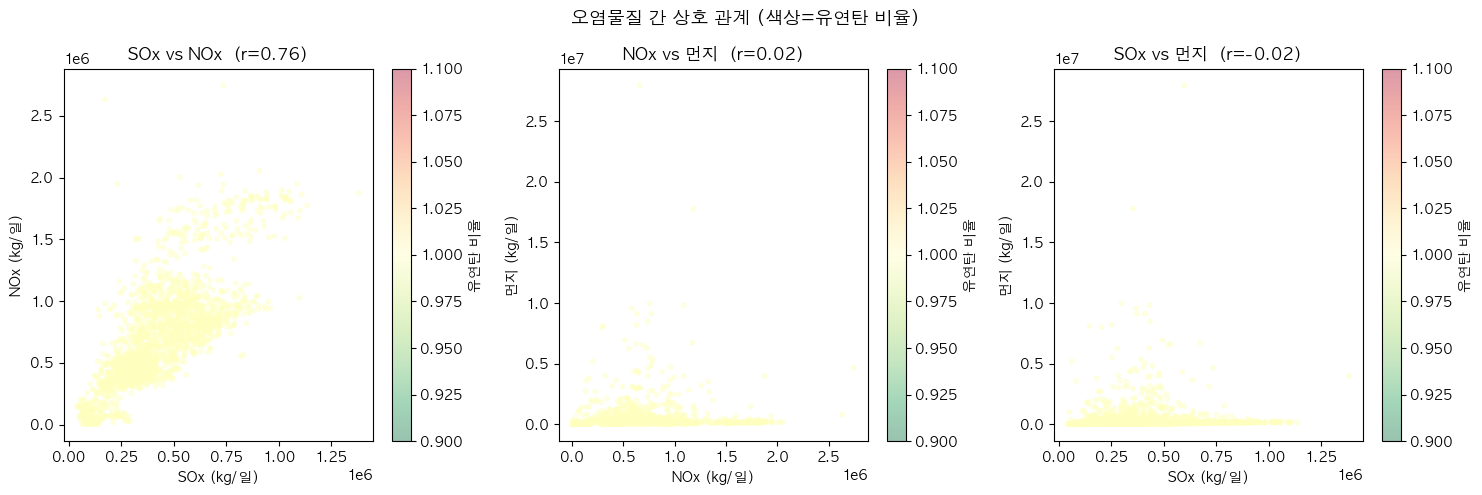

[저장] eda_07_pollutant_relations.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
pairs = [('SOx', 'NOx'), ('NOx', '먼지'), ('SOx', '먼지')]
for ax, (x_col, y_col) in zip(axes, pairs):
    if x_col not in master.columns or y_col not in master.columns:
        continue
    sc = ax.scatter(master[x_col], master[y_col],
                    c=master['coal_ratio'], cmap='RdYlGn_r', alpha=0.4, s=10)
    plt.colorbar(sc, ax=ax, label='유연탄 비율')
    r = master[[x_col, y_col]].corr().iloc[0, 1]
    ax.set_xlabel(f'{x_col} (kg/일)')
    ax.set_ylabel(f'{y_col} (kg/일)')
    ax.set_title(f'{x_col} vs {y_col}  (r={r:.2f})', fontweight='bold')

plt.suptitle('오염물질 간 상호 관계 (색상=유연탄 비율)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORT_DIR / 'eda_07_pollutant_relations.png', dpi=150, bbox_inches='tight')
plt.show()
print('[저장] eda_07_pollutant_relations.png')

## 9. 월별 기상 조건 × 배출량 히트맵

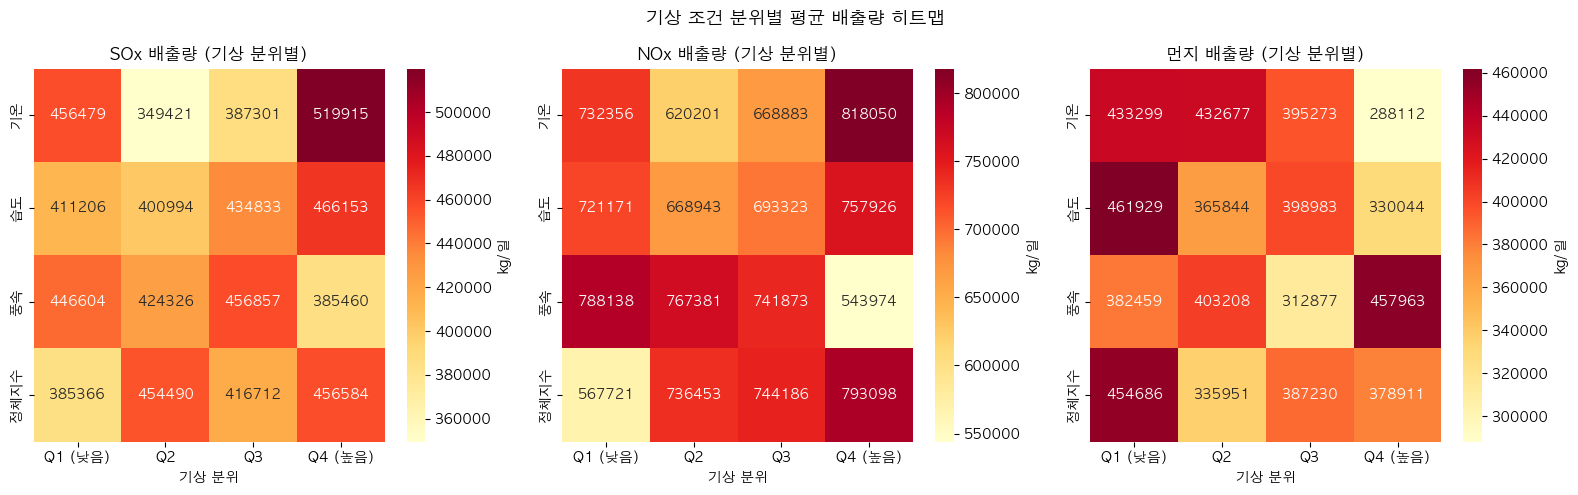

[저장] eda_08_weather_quartile_heatmap.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
weather_pivot_cols = ['temp_mean', 'humidity_mean', 'wind_speed_mean', 'stagnation_idx']

for ax, target in zip(axes, TARGET_COLS):
    if target not in master.columns:
        continue
    pivot_data = {}
    for w in weather_pivot_cols:
        if w in master.columns:
            # 기상 변수 사분위로 나눠서 배출량 평균
            labels_q = ['Q1 (낮음)', 'Q2', 'Q3', 'Q4 (높음)']
            master[f'{w}_q'] = pd.qcut(master[w], q=4, labels=labels_q, duplicates='drop')
            pivot_data[w] = master.groupby(f'{w}_q', observed=True)[target].mean()

    if pivot_data:
        pivot_df = pd.DataFrame(pivot_data).T
        pivot_df.index = ['기온', '습도', '풍속', '정체지수']
        sns.heatmap(pivot_df, annot=True, fmt='.0f', cmap='YlOrRd',
                    ax=ax, cbar_kws={'label': 'kg/일'})
        ax.set_title(f'{target} 배출량 (기상 분위별)', fontweight='bold')
        ax.set_xlabel('기상 분위')

plt.suptitle('기상 조건 분위별 평균 배출량 히트맵', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORT_DIR / 'eda_08_weather_quartile_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('[저장] eda_08_weather_quartile_heatmap.png')

## 10. 열효율 분석 — 3-경로 프레임워크

공모전 요구: "발전 설비의 열효율에 따라 배출 특성이 가변적"

**데이터로 발견한 핵심 인과 체인:**

```
기상 조건
  ├─ [경로 A] 대기정체(stagnation_idx) → 배출물 확산 저해 → 농도 위험
  ├─ [경로 B] 이용률 결정 → 연료 소비량 → 총 배출량 (이용률↓ → 총배출↓)
  └─ [경로 C] 이용률 → 열효율(r=0.72) → NOx집중도(r=-0.43) (이용률↑ → 단위당 배출↓)
```

경로 B와 C는 **반대 방향** → 대기정체일(A 위험)에는 B 우선(감발), 평상시에는 C 고려(적정부하 유지)

이용률 → 열효율 회귀: efficiency = 0.3111 × utilization + 14.62  (r=0.72)
열효율 → NOx집중도 상관: r=-0.43
  → 이용률 25% 시 예상 열효율: 22.4%
  → 이용률 65% 시 예상 열효율: 34.8%


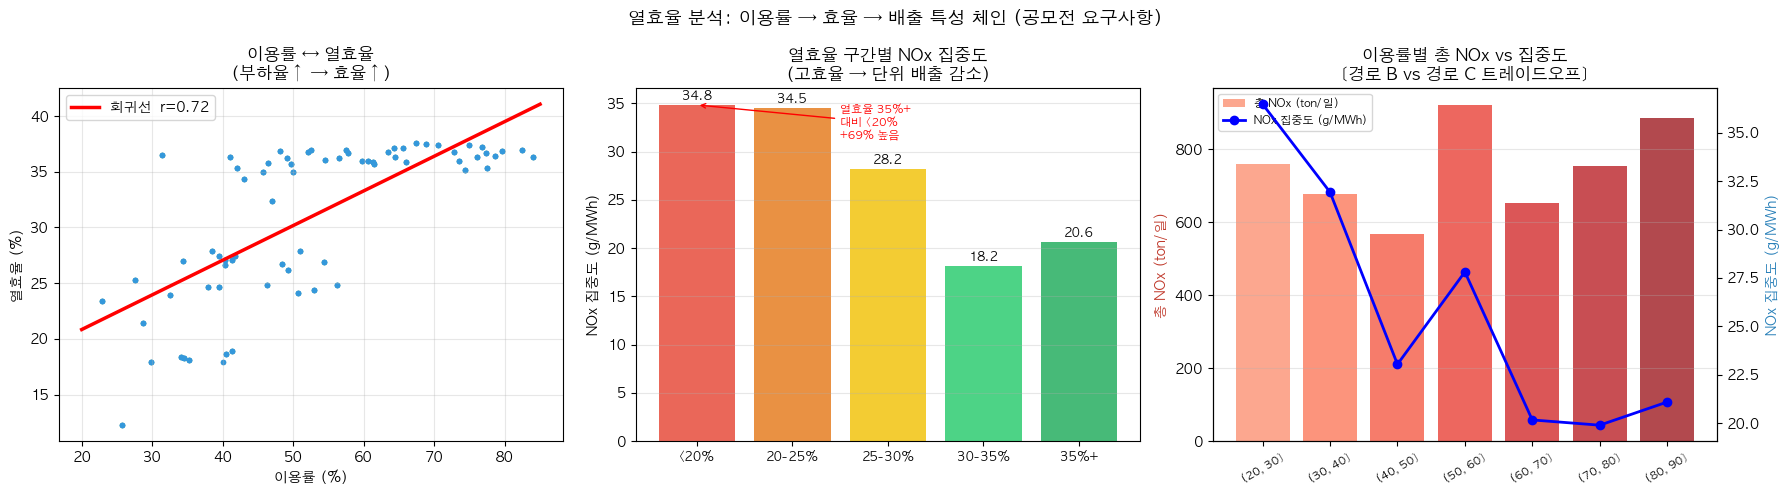

[저장] eda_09_heat_efficiency.png

핵심 수치:
  이용률 25% → 열효율 22.4% → NOx집중도 높음 (감발 시 단위 배출↑)
  이용률 65% → 열효율 34.8% → NOx집중도 낮음 (고부하 시 단위 배출↓)


In [12]:
# 배출 집중도 계산 (단위 발전당 배출량)
gen_col = 'api_gen_mwh' if 'api_gen_mwh' in master.columns else 'gen_mwh'
master['gen_mwh_combined'] = master['api_gen_mwh'].fillna(master['gen_mwh']) if 'api_gen_mwh' in master.columns else master['gen_mwh']
master['nox_intensity'] = master['NOx'] / master['gen_mwh_combined'].clip(lower=1)  # g/MWh
master['sox_intensity'] = master['SOx'] / master['gen_mwh_combined'].clip(lower=1)

# 이용률→열효율 회귀 계수 (데이터 기반)
mask = master['utilization'].notna() & master['heat_efficiency'].notna()
eff_m, eff_b = np.polyfit(master.loc[mask, 'utilization'], master.loc[mask, 'heat_efficiency'], 1)
r_util_eff = master[['utilization', 'heat_efficiency']].corr().iloc[0, 1]
r_eff_nox  = master[['heat_efficiency', 'nox_intensity']].corr().iloc[0, 1]

print(f'이용률 → 열효율 회귀: efficiency = {eff_m:.4f} × utilization + {eff_b:.2f}  (r={r_util_eff:.2f})')
print(f'열효율 → NOx집중도 상관: r={r_eff_nox:.2f}')
print(f'  → 이용률 25% 시 예상 열효율: {eff_m*25+eff_b:.1f}%')
print(f'  → 이용률 65% 시 예상 열효율: {eff_m*65+eff_b:.1f}%')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── 1) 이용률 vs 열효율 산점도 + 회귀선 ──────────────────────
ax = axes[0]
plot_mask = master['utilization'].notna() & master['heat_efficiency'].notna()
ax.scatter(master.loc[plot_mask, 'utilization'],
           master.loc[plot_mask, 'heat_efficiency'],
           alpha=0.2, s=8, color='#3498DB')
x_line = np.linspace(20, 85, 100)
ax.plot(x_line, eff_m * x_line + eff_b, 'r-', lw=2.5,
        label=f'회귀선  r={r_util_eff:.2f}')
ax.set_xlabel('이용률 (%)')
ax.set_ylabel('열효율 (%)')
ax.set_title('이용률 ↔ 열효율\n(부하율↑ → 효율↑)', fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# ── 2) 열효율 구간별 NOx 집중도 막대그래프 ───────────────────
ax = axes[1]
eff_bins   = [0, 20, 25, 30, 35, 40]
eff_labels = ['<20%', '20-25%', '25-30%', '30-35%', '35%+']
master['eff_bin'] = pd.cut(master['heat_efficiency'], bins=eff_bins, labels=eff_labels)
nox_by_eff = master.groupby('eff_bin', observed=True)['nox_intensity'].mean()
bars = ax.bar(range(len(nox_by_eff)), nox_by_eff.values,
              color=['#E74C3C','#E67E22','#F1C40F','#2ECC71','#27AE60'], alpha=0.85)
for bar, val in zip(bars, nox_by_eff.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(range(len(nox_by_eff)))
ax.set_xticklabels(eff_labels, fontsize=9)
ax.set_ylabel('NOx 집중도 (g/MWh)')
ax.set_title('열효율 구간별 NOx 집중도\n(고효율 → 단위 배출 감소)', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
# 35%+ 대비 <20% 증가율 표시
ax.annotate(f"열효율 35%+\n대비 <20%\n+{(nox_by_eff.iloc[0]/nox_by_eff.iloc[-1]-1)*100:.0f}% 높음",
            xy=(0, nox_by_eff.iloc[0]), xytext=(1.5, nox_by_eff.iloc[0]*0.9),
            arrowprops=dict(arrowstyle='->', color='red'), fontsize=8, color='red')

# ── 3) 이용률별 총 NOx vs 집중도 (경로 B vs C 트레이드오프) ──
ax3 = axes[2]
ax3_twin = ax3.twinx()
util_bins = pd.cut(master['utilization'], bins=range(20, 95, 10))
total_nox = master.groupby(util_bins, observed=True)['NOx'].mean() / 1e3      # ton/일
intensity  = master.groupby(util_bins, observed=True)['nox_intensity'].mean()
n_bins = len(total_nox)
bar_colors = plt.cm.Reds(np.linspace(0.4, 0.9, n_bins))
ax3.bar(range(n_bins), total_nox.values, color=bar_colors, alpha=0.75, label='총 NOx (ton/일)')
ax3_twin.plot(range(n_bins), intensity.values, 'b-o', lw=2, ms=6, label='NOx 집중도 (g/MWh)')
ax3.set_xticks(range(n_bins))
ax3.set_xticklabels([str(iv) for iv in total_nox.index], rotation=30, fontsize=8)
ax3.set_ylabel('총 NOx (ton/일)', color='#C0392B')
ax3_twin.set_ylabel('NOx 집중도 (g/MWh)', color='#2980B9')
ax3.set_title('이용률별 총 NOx vs 집중도\n[경로 B vs 경로 C 트레이드오프]', fontweight='bold')
lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3_twin.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper left')
ax3.grid(axis='y', alpha=0.3)

plt.suptitle('열효율 분석: 이용률 → 효율 → 배출 특성 체인 (공모전 요구사항)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORT_DIR / 'eda_09_heat_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()
print('[저장] eda_09_heat_efficiency.png')
print(f'\n핵심 수치:')
print(f'  이용률 25% → 열효율 {eff_m*25+eff_b:.1f}% → NOx집중도 높음 (감발 시 단위 배출↑)')
print(f'  이용률 65% → 열효율 {eff_m*65+eff_b:.1f}% → NOx집중도 낮음 (고부하 시 단위 배출↓)')

## 10. 핵심 인사이트 요약 (보고서 Ⅱ장)

In [13]:
print('=' * 60)
print('EDA 핵심 인사이트 요약')
print('=' * 60)

# 1. 대기정체 영향
if 'stagnation_idx' in master.columns:
    low = master[master['stagnation_idx'] <= master['stagnation_idx'].quantile(0.1)]
    high = master[master['stagnation_idx'] >= master['stagnation_idx'].quantile(0.9)]
    for t in TARGET_COLS:
        if t in master.columns:
            inc = (high[t].mean() - low[t].mean()) / low[t].mean() * 100
            print(f'\n[대기정체 영향] {t}: 정체 심각 시 +{inc:.1f}% 증가')

# 2. 유연탄 비율 상관
if 'coal_ratio' in master.columns:
    for t in TARGET_COLS:
        if t in master.columns:
            r = master[['coal_ratio', t]].corr().iloc[0, 1]
            print(f'\n[연료 영향] coal_ratio vs {t} 상관계수: r={r:.3f}')

# 3. 계절성
for t in TARGET_COLS:
    if t in master.columns:
        season_mean = master.groupby('season')[t].mean()
        max_s = season_mean.idxmax()
        min_s = season_mean.idxmin()
        labels = {'spring':'봄','summer':'여름','autumn':'가을','winter':'겨울'}
        print(f'\n[계절성] {t}: 최고={labels.get(max_s,max_s)}({season_mean[max_s]:.0f}), '
              f'최저={labels.get(min_s,min_s)}({season_mean[min_s]:.0f})')

print('\n' + '=' * 60)
print(f'저장된 EDA 시각화: {list(REPORT_DIR.glob("eda_*.png"))}')

EDA 핵심 인사이트 요약

[대기정체 영향] SOx: 정체 심각 시 +28.0% 증가

[대기정체 영향] NOx: 정체 심각 시 +51.9% 증가

[대기정체 영향] 먼지: 정체 심각 시 +-23.2% 증가

[연료 영향] coal_ratio vs SOx 상관계수: r=nan

[연료 영향] coal_ratio vs NOx 상관계수: r=nan

[연료 영향] coal_ratio vs 먼지 상관계수: r=nan

[계절성] SOx: 최고=여름(498953), 최저=봄(349597)

[계절성] NOx: 최고=여름(820830), 최저=봄(607298)

[계절성] 먼지: 최고=겨울(529215), 최저=여름(280296)

저장된 EDA 시각화: [PosixPath('../reports/eda_03_correlation_heatmap.png'), PosixPath('../reports/eda_07_pollutant_relations.png'), PosixPath('../reports/eda_09_heat_efficiency.png'), PosixPath('../reports/eda_06_renewable_emission.png'), PosixPath('../reports/eda_04_stagnation_analysis.png'), PosixPath('../reports/eda_08_weather_quartile_heatmap.png'), PosixPath('../reports/eda_05_fuel_mix_scatter.png'), PosixPath('../reports/eda_02_seasonal_pattern.png'), PosixPath('../reports/eda_01_timeseries.png')]
